# Advanced diagnostic: layer statistics and LoRA subsets

Compare descriptive hidden-state and adapter statistics before/after adaptation. Test rank-4 query/value LoRA in the first six versus the final six of the inspected 24 blocks. Data, epochs, learning rate, seed, formatter and benchmark stay fixed. A changed statistic does not establish that a layer caused a semantic behavior.

Calibration uses two training recipes only, identical token IDs and eval mode. For activations H, report mean, population standard deviation, RMS $\sqrt{\mathrm{mean}(H^2)}$ and maximum absolute value. For an adapter, $\Delta W=(\alpha/r)BA$; relative update size is $\|\Delta W\|_F/\|W\|_F$. Larger changes need not imply useful learning.

In [1]:
from pathlib import Path
import sys, subprocess, json
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'ml' / 'training' / 'sft.py').exists()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from the complete RecipeTriage checkout.')
print('Project:', ROOT, 'Kernel:', sys.executable)
try:
    import recipetriage_ml
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--no-deps', '-e', str(ROOT / 'ml')])
    import importlib; importlib.invalidate_caches()
    import recipetriage_ml
RESULTS = ROOT / 'ml' / 'analysis' / 'results' / 'layers-v1'


Project: /Users/smohandoss/Documents/Codex/2026-09-09/files-mentioned-by-the-user-recipetriage/outputs/recipetriage Kernel: /Users/smohandoss/Documents/Codex/2026-09-09/files-mentioned-by-the-user-recipetriage/outputs/recipetriage/.venv/bin/python


## Inspect valid modules

Select full module paths from the actual pinned architecture. Reject invalid indices. Both six-layer subsets use the same adapter budget. The all-layer reference has a larger budget and is contextual evidence only.

In [2]:
from recipetriage_ml.training.lora import architecture_report, target_paths, estimated_parameters
architecture = architecture_report()
subsets = {'early-six': list(range(6)), 'late-six': list(range(18, 24))}
print('Architecture:', architecture['class'], 'blocks:', architecture['layers'])
for name, layers in subsets.items():
    paths = target_paths(architecture, 'query-value', layers)
    print(name, 'parameters:', estimated_parameters(architecture, 4, layers=layers), 'targets:', len(paths))
    print(paths[:2], '...', paths[-2:])

Architecture: Qwen2ForCausalLM blocks: 24
early-six parameters: 67584 targets: 12
['model.layers.0.self_attn.q_proj', 'model.layers.0.self_attn.v_proj'] ... ['model.layers.5.self_attn.q_proj', 'model.layers.5.self_attn.v_proj']
late-six parameters: 67584 targets: 12
['model.layers.18.self_attn.q_proj', 'model.layers.18.self_attn.v_proj'] ... ['model.layers.23.self_attn.q_proj', 'model.layers.23.self_attn.v_proj']


## Optional rerun

By default, read the delivered measurements. Set RUN_EXPERIMENT to True to run two new CPU training jobs and two ten-case benchmarks. Install the documented HF/SFT dependencies into this kernel first. The CPU experiment takes several minutes and writes a new directory.

In [3]:
RUN_EXPERIMENT = False
if RUN_EXPERIMENT:
    import os
    from datetime import datetime, timezone
    from recipetriage_ml.analysis.layers import run
    os.environ.setdefault('HF_HOME', str(ROOT / '.cache' / 'huggingface'))
    RESULTS = ROOT / 'ml' / 'analysis' / 'runs' / datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')
    run(RESULTS)
if not (RESULTS / 'comparison.json').exists():
    raise FileNotFoundError('Measured layer results are not available yet. Run the documented experiment command.')
comparison = json.loads((RESULTS / 'comparison.json').read_text())
comparison

{'dataset_version': 'v1-63135eef80fb9be90547673e7f13d4142eb0eb29852cf098e672b44fca20158f',
 'benchmark_sha256': '173e79cc1968dd1207a7aafd051dad40d87ff551c7081a17b896c9556a698448',
 'calibration_recipe_ids': ['seed-001', 'seed-002'],
 'results': [{'name': 'early-six',
   'layers': [0, 1, 2, 3, 4, 5],
   'run_id': 'c16561d0-9328-489e-b67b-19c53c7ca288',
   'trainable_parameters': 67584,
   'training_seconds': 29.866796375019476,
   'micro_f1': 0.19047619047619047,
   'macro_f1': 0.1285714285714286,
   'statistics_file': 'early-six-statistics.json'},
  {'name': 'late-six',
   'layers': [18, 19, 20, 21, 22, 23],
   'run_id': 'b530230c-018f-4ae5-a3cc-5f6bbf713fd3',
   'trainable_parameters': 67584,
   'training_seconds': 16.35039166698698,
   'micro_f1': 0.43243243243243246,
   'macro_f1': 0.32653061224489793,
   'statistics_file': 'late-six-statistics.json'}],
 'limitations': ['Two recipes and one run per subset do not support causal explanations.',
  'Activation scale changes can reflect 

In [4]:
import pandas as pd
scores = pd.DataFrame(comparison['results'])
display(scores[['name', 'layers', 'trainable_parameters', 'training_seconds', 'micro_f1', 'macro_f1']])
print('One run per subset on ten provisional cases does not establish a general ranking.')

,name,layers,trainable_parameters,training_seconds,micro_f1,macro_f1
0,early-six,"[0, 1, 2, 3, 4, 5]",67584,29.866796,0.190476,0.128571
1,late-six,"[18, 19, 20, 21, 22, 23]",67584,16.350392,0.432432,0.326531


One run per subset on ten provisional cases does not establish a general ranking.


In [5]:
frames = []
for row in comparison['results']:
    data = json.loads((RESULTS / row['statistics_file']).read_text())
    before = pd.DataFrame(data['before'])
    after = pd.DataFrame(data['after'])
    merged = before.merge(after, on=['recipe_id', 'hidden_state_index'], suffixes=('_before', '_after'))
    assert (merged.input_ids_sha256_before == merged.input_ids_sha256_after).all()
    assert (merged.tokens_before == merged.tokens_after).all()
    merged['rms_delta'] = merged.rms_after - merged.rms_before
    merged['subset'] = row['name']
    frames.append(merged)
statistics = pd.concat(frames, ignore_index=True)
display(statistics[['subset', 'recipe_id', 'hidden_state_index', 'rms_before', 'rms_after', 'rms_delta']])

,subset,recipe_id,hidden_state_index,rms_before,rms_after,rms_delta
0,early-six,seed-001,0,0.015531,0.015531,0.000000
1,early-six,seed-001,1,0.189261,0.189415,0.000155
2,early-six,seed-001,2,0.271085,0.271067,-0.000018
3,early-six,seed-001,3,1.356119,1.339923,-0.016196
4,early-six,seed-001,4,2.997139,2.980894,-0.016245
...,...,...,...,...,...,...
95,late-six,seed-002,20,3.267601,3.267336,-0.000265
96,late-six,seed-002,21,3.458900,3.457974,-0.000926
97,late-six,seed-002,22,2.275052,2.273510,-0.001542
98,late-six,seed-002,23,2.479975,2.478925,-0.001050


Matplotlib is building the font cache; this may take a moment.


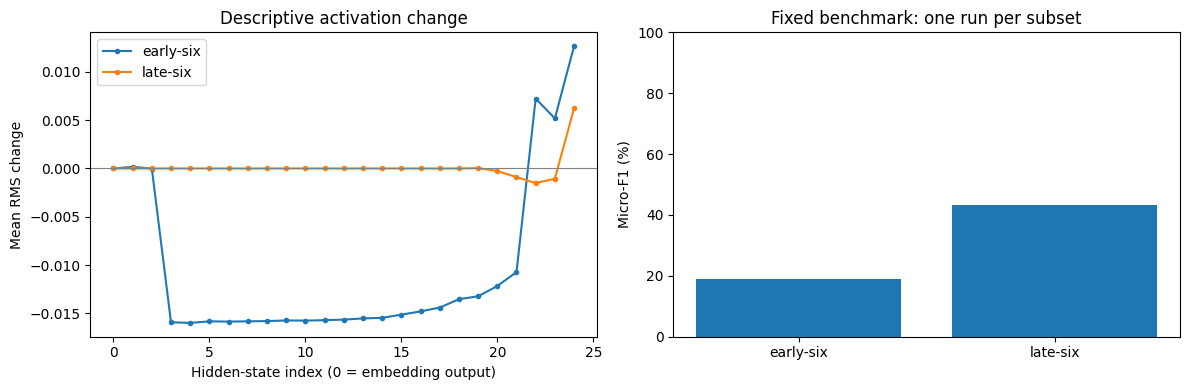

In [6]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, group in statistics.groupby('subset'):
    summary = group.groupby('hidden_state_index').rms_delta.mean()
    axes[0].plot(summary.index, summary.values, marker='.', label=name)
axes[0].axhline(0, color='gray', linewidth=.8)
axes[0].set(xlabel='Hidden-state index (0 = embedding output)', ylabel='Mean RMS change', title='Descriptive activation change')
axes[0].legend()
axes[1].bar(scores.name, scores.micro_f1 * 100)
axes[1].set(ylabel='Micro-F1 (%)', ylim=(0, 100), title='Fixed benchmark: one run per subset')
fig.tight_layout()
fig.savefig(RESULTS / 'layer-diagnostics.png', dpi=150)
plt.show()

## Interpretation limits

Compare task scores alongside parameters and time. Do not call a block a timing layer because activations changed on a timing recipe. Downstream activations can change even when their weights are frozen. Coordinate/scaling changes can alter RMS without improving a useful representation.

This subset intervention changes where the trainable matrices sit. It does not isolate one neuron, prove a learned feature or provide uncertainty from repeated seeds. A stronger follow-up would predeclare more seeds, reviewed calibration data and untouched evaluation cases. Production selection cannot use these weak signals.

Questions: Why can a frozen downstream block change its activations? Why compare identical tokens? Why can a larger update norm yield worse F1? What stays fixed between the runs? What extra evidence would support causality?